In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file = '/content/drive/MyDrive/Tumor_Dataset.zip'

In [ ]:
import zipfile as zf
data_zip = zf.ZipFile(file)
data_zip.extractall()
!ls

drive  sample_data  Tumor_Dataset


In [ ]:
from pathlib import Path
data = Path(r'/content/Tumor_Dataset')

In [ ]:
#list of useful libraries required for the project
import os
import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
from glob import glob
import seaborn as sns
import random
from keras.preprocessing import image
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPool2D,GlobalAvgPool2D,GlobalMaxPooling2D
from keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [ ]:
images=[]
import os
for dirname,_,filenames in os.walk(data):
  for filename in filenames:
    file_name, file_extension = os.path.splitext(filename)
    if file_extension == '.db':
      continue
    else:
      img=os.path.join(dirname,filename)
      images.append(img)

In [ ]:
images[:20]

['/content/Tumor_Dataset/pituitary_tumor/p (83).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (565).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (708).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (373).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (819).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (791).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (178).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (442).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (447).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (809).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (183).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (655).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (142).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (469).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (756).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (180).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (632).jpg',
 '/content/Tumor_Dataset/pituitary_tumor/p (19).jpg',
 '/content/T

In [ ]:
len(images)

2870

In [ ]:
class_values = []
for i in images:
    j = i.split('/')
    class_values.append(j[-2])

In [ ]:
class_values[:10]

['pituitary_tumor',
 'pituitary_tumor',
 'pituitary_tumor',
 'pituitary_tumor',
 'pituitary_tumor',
 'pituitary_tumor',
 'pituitary_tumor',
 'pituitary_tumor',
 'pituitary_tumor',
 'pituitary_tumor']

In [ ]:
import random # Import the random module at the beginning of the cell
temp = list(zip(images,class_values))
random.shuffle(temp)
images, class_values = zip(*temp)
data = pd.DataFrame(list(zip(images, class_values)), columns=['image_path', 'Class_label'])

In [ ]:
data

,image_path,Class_label
0,/content/Tumor_Dataset/pituitary_tumor/p (38).jpg,pituitary_tumor
1,/content/Tumor_Dataset/glioma_tumor/gg (266).jpg,glioma_tumor
2,/content/Tumor_Dataset/no_tumor/image (27).jpg,no_tumor
3,/content/Tumor_Dataset/pituitary_tumor/p (402)...,pituitary_tumor
4,/content/Tumor_Dataset/no_tumor/image(146).jpg,no_tumor
...,...,...
2865,/content/Tumor_Dataset/meningioma_tumor/m (137...,meningioma_tumor
2866,/content/Tumor_Dataset/meningioma_tumor/m2 (11...,meningioma_tumor
2867,/content/Tumor_Dataset/glioma_tumor/gg (339).jpg,glioma_tumor
2868,/content/Tumor_Dataset/meningioma_tumor/m2 (16...,meningioma_tumor


In [ ]:
data.shape

(2870, 2)

In [ ]:
data.Class_label.value_counts()

,count
Class_label,
pituitary_tumor,827
glioma_tumor,826
meningioma_tumor,822
no_tumor,395


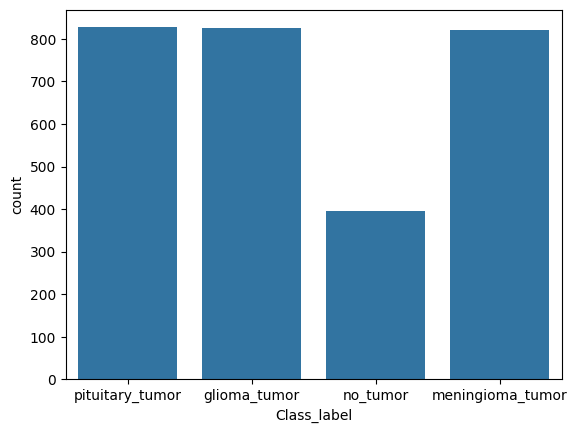

In [ ]:
sns.countplot(x = data.Class_label, data = data)
plt.show()

In [ ]:
from sklearn.utils import resample

# The original filter was using integers (1 and 0) but the 'Class_label' column seems to contain strings
# Correcting the filter condition to use strings ('1' and '0') should fix the issue
df_c0 = data[data['Class_label'] == 'pituitary_tumor']
df_c1 = data[data['Class_label'] == 'glioma_tumor']
df_c2 = data[data['Class_label'] == 'meningioma_tumor']
df_c3 = data[data['Class_label'] == 'no_tumor']


unsampled_df_c0 = resample(df_c0, replace=True, random_state=23, n_samples=2000)
unsampled_df_c1 = resample(df_c1, replace=True, random_state=23, n_samples=2000)
unsampled_df_c2 = resample(df_c2, replace=True, random_state=23, n_samples=2000)
unsampled_df_c3 = resample(df_c3, replace=True, random_state=23, n_samples=2000)

df_unsampled = pd.concat([unsampled_df_c0, unsampled_df_c1, unsampled_df_c2, unsampled_df_c3])
df_unsampled

,image_path,Class_label
2047,/content/Tumor_Dataset/pituitary_tumor/p (238)...,pituitary_tumor
2572,/content/Tumor_Dataset/pituitary_tumor/p (204)...,pituitary_tumor
123,/content/Tumor_Dataset/pituitary_tumor/p (476)...,pituitary_tumor
1701,/content/Tumor_Dataset/pituitary_tumor/p (103)...,pituitary_tumor
100,/content/Tumor_Dataset/pituitary_tumor/p (781)...,pituitary_tumor
...,...,...
2721,/content/Tumor_Dataset/no_tumor/image(290).jpg,no_tumor
940,/content/Tumor_Dataset/no_tumor/image(102).jpg,no_tumor
2199,/content/Tumor_Dataset/no_tumor/image(179).jpg,no_tumor
2736,/content/Tumor_Dataset/no_tumor/image (57).jpg,no_tumor


In [ ]:
df_unsampled.Class_label.value_counts()

,count
Class_label,
pituitary_tumor,2000
glioma_tumor,2000
meningioma_tumor,2000
no_tumor,2000


In [ ]:
data = df_unsampled.sample(frac=1)
data.shape

(8000, 2)

In [ ]:
df = data

In [ ]:
import os
from PIL import Image

In [ ]:
def resize_images(img):
  file = Image.open(img)
  img = file.convert('RGB')
  img_bgr= img.resize((124, 124))
  img_bgr = np.array(img_bgr)
  return img_bgr

In [ ]:
#save resized images into images.
images = [resize_images(img) for img in df['image_path']]

In [ ]:
images

[array([[[ 0,  0,  0],
         [ 1,  1,  1],
         [ 2,  2,  2],
         ...,
         [ 2,  2,  2],
         [ 1,  1,  1],
         [ 1,  1,  1]],
 
        [[ 3,  3,  3],
         [ 4,  4,  4],
         [ 5,  5,  5],
         ...,
         [ 4,  4,  4],
         [ 4,  4,  4],
         [ 4,  4,  4]],
 
        [[ 5,  5,  5],
         [ 8,  8,  8],
         [ 9,  9,  9],
         ...,
         [ 6,  6,  6],
         [ 7,  7,  7],
         [ 6,  6,  6]],
 
        ...,
 
        [[ 5,  5,  5],
         [ 7,  7,  7],
         [ 7,  7,  7],
         ...,
         [ 8,  8,  8],
         [10, 10, 10],
         [ 7,  7,  7]],
 
        [[ 2,  2,  2],
         [ 2,  2,  2],
         [ 2,  2,  2],
         ...,
         [ 6,  6,  6],
         [ 7,  7,  7],
         [ 4,  4,  4]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 1,  1,  1],
         [ 1,  1,  1],
         [ 1,  1,  1]]], dtype=uint8),
 array([[[0, 0, 0],
         [0, 0, 0],
  

In [ ]:
# print number of classes in our dataset
num_classes = len(np.unique(data['Class_label']))
num_classes

4

In [ ]:
# save the class into class_names
class_names = list(data['Class_label'])

In [ ]:
# Print the shape of the image
images[25].shape

(124, 124, 3)

Text(0.5, 1.0, 'meningioma_tumor')

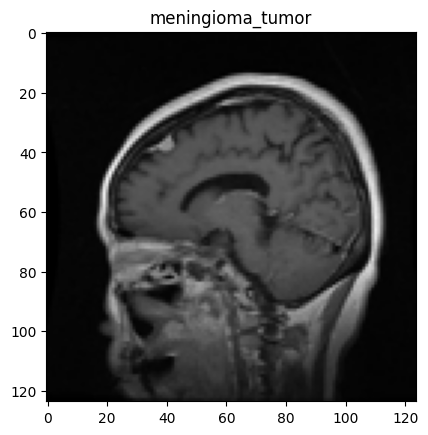

In [ ]:
#See the image with class label
plt.imshow(images[20])
plt.title(class_names[20])

Text(0.5, 1.0, 'meningioma_tumor')

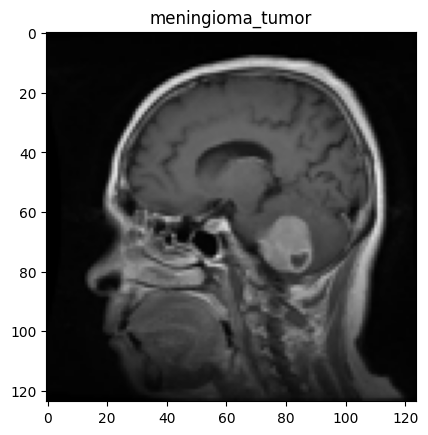

In [ ]:
#See the image with class label
plt.imshow(images[250])
plt.title(class_names[250])

In [ ]:
# Convert the images into array
images =  np.array(images)

In [ ]:
# Shape of the images
images.shape

(8000, 124, 124, 3)

In [ ]:
from sklearn.preprocessing import LabelEncoder
enc=LabelEncoder()
Y = enc.fit_transform(df['Class_label'])
from keras.utils  import to_categorical
y = to_categorical(Y)

In [ ]:
enc.classes_

array(['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor'],
      dtype=object)

In [ ]:
y[:10]

array([[0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.]])

In [ ]:
y.shape

(8000, 4)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, y, test_size=0.3,stratify = y,random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision

# ================================
# Enable Mixed Precision
# ================================
mixed_precision.set_global_policy('mixed_float16')

# ================================
# Image size & Training Parameters
# ================================
IMG_SIZE = 124
BATCH_SIZE = 64
EPOCHS = 50

# ================================
# Data Augmentation
# ================================
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=BATCH_SIZE
)

# ================================
# Load ResNet50 (without top)
# ================================
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model
base_model.trainable = False

# ================================
# Custom Classification Head
# ================================
x = GlobalAveragePooling2D()(base_model.output)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(4, activation='softmax', dtype='float32')(x)

# ================================
# Build Model
# ================================
model = Model(inputs=base_model.input, outputs=output)

# ================================
# Compile
# ================================
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ================================
# Callbacks
# ================================
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7
)

# ================================
# Train
# ================================
history = model.fit(
    train_generator,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 59s 467ms/step - accuracy: 0.5215 - loss: 1.2955 - val_accuracy: 0.7779 - val_loss: 0.6107 - learning_rate: 1.0000e-04
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step - accuracy: 0.7406 - loss: 0.6764 - val_accuracy: 0.8233 - val_loss: 0.4892 - learning_rate: 1.0000e-04
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step - accuracy: 0.7956 - loss: 0.5506 - val_accuracy: 0.8517 - val_loss: 0.4176 - learning_rate: 1.0000e-04
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step - accuracy: 0.8320 - loss: 0.4713 - val_accuracy: 0.8637 - val_loss: 0.3767 - learning_rate: 1.0000e-04
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 280ms/step - accuracy: 0.8257 - loss: 0.4549 - val_accuracy: 0.8763 - val_loss: 0.3678 - learning_rate: 1.0000e-04
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 282ms/step - accuracy: 0.8603 - loss: 0.3947 - val_accuracy: 0.8829 - val_loss: 0.3299 - learning_rate: 1.0000e-04
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 293ms/step - acc

In [ ]:
# Evaluate the trained ResNet model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy (ResNet): {test_acc * 100:.2f}%")

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9361 - loss: 0.1584
Test Accuracy (ResNet): 93.88%


In [ ]:
# Save the trained ResNet model
model.save("brain_tumor_RESNET.h5")
print("Model saved successfully as brain_tumor_resnet.h5")

Model saved successfully as brain_tumor_resnet.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


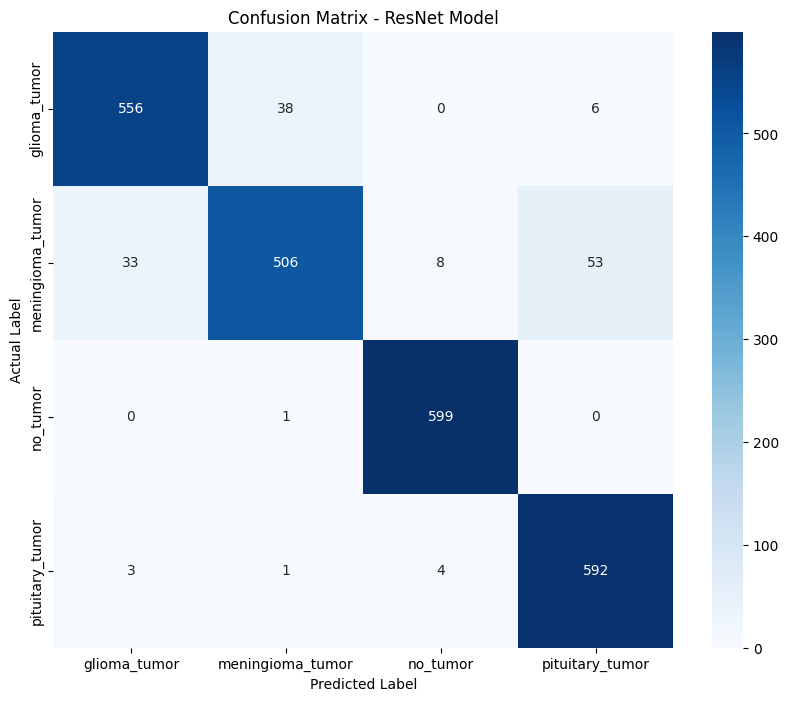

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Generate the confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# 3. Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=enc.classes_,
    yticklabels=enc.classes_
)
plt.title('Confusion Matrix - ResNet Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

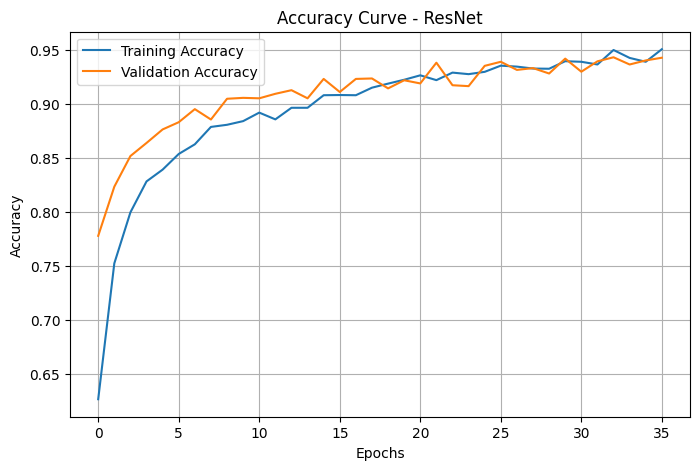

In [ ]:
import matplotlib.pyplot as plt
# Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve - ResNet')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

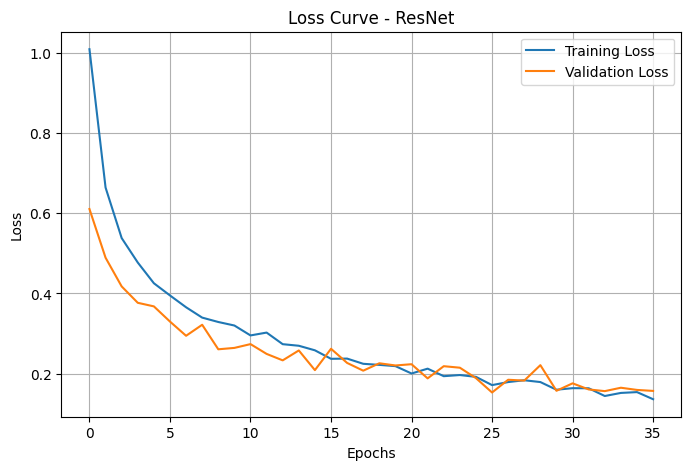

In [ ]:
# Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve - ResNet')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


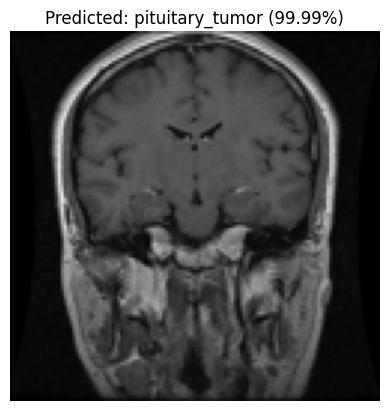

In [ ]:
# 1. Select an image path
test_img_path = data.iloc[0]['image_path'] # Change this to any image path

# 2. Preprocess the image
def prepare_image(path):
    img = resize_images(path)
    img = np.expand_dims(img, axis=0) # Add batch dimension
    return img

processed_img = prepare_image(test_img_path)

# 3. Make prediction
prediction = model.predict(processed_img)
predicted_class_idx = np.argmax(prediction)
predicted_class_name = enc.classes_[predicted_class_idx]
confidence = np.max(prediction) * 100

# 4. Display Result
plt.imshow(resize_images(test_img_path))
plt.title(f"Predicted: {predicted_class_name} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

In [ ]:
sample = X_test[10]
sample = np.expand_dims(sample, axis=0)
print(model.predict(sample))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[2.1777087e-05 1.1097514e-05 9.9987721e-01 8.9863082e-05]]
